# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Observations of Merged CRSP Data and Robintrack Data

The data sample runs from June, 1st 2018 to August, 13 2020

---

In [8]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Once the libraries are loaded, I load the data.

In [9]:
# load data
df = pd.read_csv("../../data/processed/CRSP_RH_merged.csv")

## 1. Exploratory Data Analysis

In this section, I conduct a basic EDA on this first data set.

In [10]:
# observe the missing values
df.isna().sum()

date                0
users_close    784229
users_last     776486
ticker              0
permno              0
ret                 0
prc                 0
vol                 0
shrout              0
exchcd              0
dtype: int64

In [11]:
# length of the data frame
len(df)

4431180

In [15]:
# number of unique tickers
unique_tickers = set(df["ticker"])
print(f"Number of unique tickers: {len(unique_tickers)}")

# write the list of 9007 unique tickers to a csv file with "ticker" as column name
unique_tickers = pd.DataFrame(list(unique_tickers), columns=["ticker"])
unique_tickers.to_csv("../../data/interim/tickers_9007.csv", index=False)


Number of unique tickers: 9007


In [13]:
# retrive unique tickers of Barber et al. (2022) main sample
# and create a list of those tickers
with open("../../data/replication/unique_tickers_main_pseudo.txt", "r") as f:
    unique_tickers_barber_main = set(line.strip() for line in f)

# check how many of the unique tickers from Barber et al. (2022) are in our merged dataset
unique_tickers_merged = set(df["ticker"].unique())
overlap_tickers = unique_tickers_barber_main.intersection(unique_tickers_merged)
print(f"Number of unique tickers in Barber et al. (2022) main sample: {len(unique_tickers_barber_main)}")
print(f"Number of unique tickers in our merged dataset: {len(unique_tickers_merged)}")
print(f"Number of overlapping unique tickers: {len(overlap_tickers)}")


Number of unique tickers in Barber et al. (2022) main sample: 8447
Number of unique tickers in our merged dataset: 9007
Number of overlapping unique tickers: 7936


In [219]:
# summary statistics for the overlapping tickers
df_overlap = df.copy()
df_overlap = df_overlap[df_overlap["ticker"].isin(overlap_tickers)]
df_overlap[["users_close", "users_last", "prc", "ret"]].describe().T

,count,mean,std,min,25%,50%,75%,max
users_close,3640675.0,2214.804518,16203.091298,0.00000,42.000000,181.00000,741.000000,990444.000000
users_last,3648417.0,2213.886449,16200.005597,0.00000,42.000000,181.00000,741.000000,990587.000000
prc,4186355.0,38.990965,91.181029,-753.28003,9.240000,22.68000,45.250000,4699.000000
ret,4186355.0,0.000407,0.042694,-1.00000,-0.009656,0.00018,0.009709,10.251815


In [220]:
df.head()

,date,users_close,users_last,ticker,permno,ret,prc,vol,shrout,exchcd
0,2018-05-01,NaN,NaN,JJSF,10026,-0.038862,132.07001,102619.0,18702.0,3.0
1,2018-05-02,NaN,NaN,JJSF,10026,-0.018248,129.66000,74013.0,18702.0,3.0
2,2018-05-03,NaN,NaN,JJSF,10026,-0.006478,128.82001,60755.0,18702.0,3.0
3,2018-05-04,NaN,NaN,JJSF,10026,0.030119,132.70000,55396.0,18702.0,3.0
4,2018-05-07,NaN,NaN,JJSF,10026,0.017709,135.05000,95096.0,18702.0,3.0


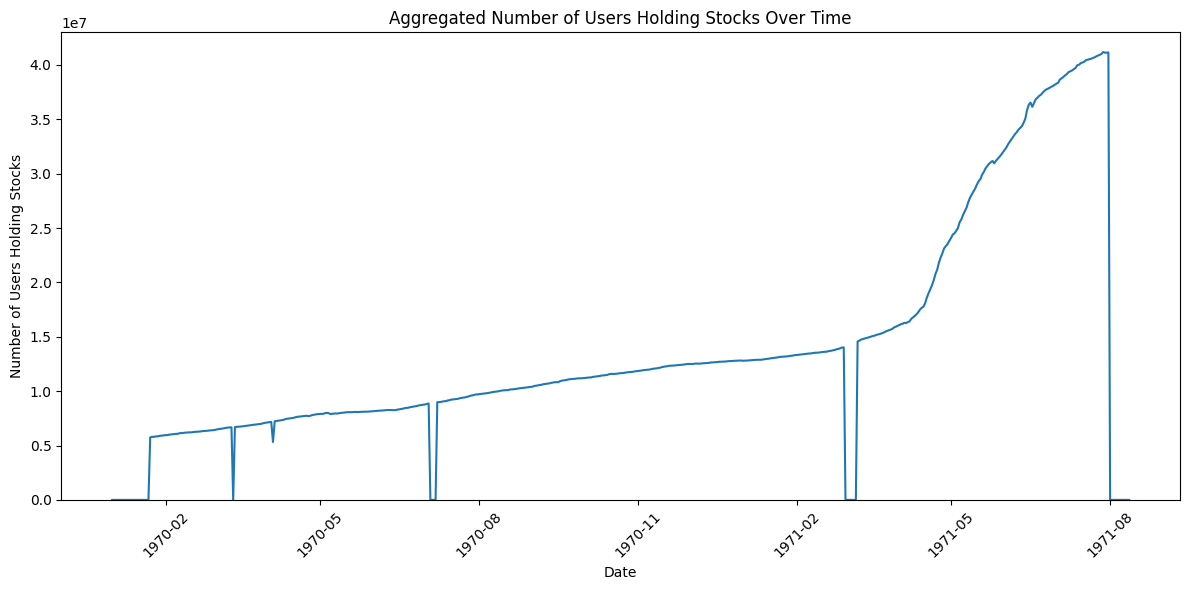

In [221]:
import matplotlib.dates as mdates

# for each day, compute the aggregated number of users_close
users_holding = (
    df.groupby("date")["users_close"]
    .sum()
    .sort_index()
)

# plot
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=users_holding.index, y=users_holding.values, ax=ax)

ax.set_ylim(0, 4.3 * 10e6)
ax.set_title("Aggregated Number of Users Holding Stocks Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Users Holding Stocks")

# show fewer ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # one tick every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [222]:
# summary statistics of users_close and users_last
df.describe().T

,count,mean,std,min,25%,50%,75%,max
users_close,3646951.0,2.213117e+03,1.619018e+04,0.00000,42.000000,181.000000,741.000000,9.904440e+05
users_last,3654694.0,2.212205e+03,1.618713e+04,0.00000,42.000000,181.000000,741.000000,9.905870e+05
permno,4431180.0,4.773909e+04,3.458631e+04,10026.00000,15722.000000,19197.000000,87121.000000,9.343600e+04
ret,4431180.0,3.643828e-04,4.351976e-02,-1.00000,-0.009687,0.000113,0.009658,1.025182e+01
prc,4431180.0,7.860510e+01,3.537492e+03,-753.28003,8.770000,22.130000,44.090000,3.449700e+05
vol,4431180.0,1.072737e+06,4.909992e+06,0.00000,17997.000000,133030.000000,625292.000000,1.003256e+09
shrout,4431180.0,9.984191e+04,3.406244e+05,5.00000,7243.000000,27495.000000,75000.000000,1.710254e+07
exchcd,4431180.0,2.587796e+00,1.233681e+00,1.00000,1.000000,3.000000,3.000000,3.100000e+01


In [223]:
# remove the rows with missing values in users_close and users_last
df_clean = df.dropna(subset=["users_close", "users_last"])

# compute summary statistics of users_close and users_last after removing missing values
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
users_close,3646951.0,2.213117e+03,1.619018e+04,0.00000,42.000000,181.000000,741.000000,9.904440e+05
users_last,3646951.0,2.214550e+03,1.620103e+04,0.00000,42.000000,181.000000,742.000000,9.905870e+05
permno,3646951.0,4.871121e+04,3.464054e+04,10026.00000,15786.000000,24643.000000,87656.000000,9.343600e+04
ret,3646951.0,3.926319e-04,4.261181e-02,-1.00000,-0.009958,0.000197,0.009991,1.025182e+01
prc,3646951.0,4.009424e+01,9.298736e+01,-753.28003,9.720000,23.065000,46.270000,4.699000e+03
vol,3646951.0,1.109092e+06,4.909551e+06,0.00000,21950.000000,147802.000000,666031.500000,1.003256e+09
shrout,3646951.0,1.050014e+05,3.562847e+05,9.00000,8150.000000,28892.000000,78864.000000,1.013935e+07
exchcd,3646951.0,2.557884e+00,1.229584e+00,1.00000,1.000000,3.000000,3.000000,6.000000e+00


In [224]:
df_clean_pos = df_clean.copy()
df_clean_pos["prc"] = df_clean_pos["prc"].abs()
df_clean_pos[['users_close', 'users_last', 'prc', 'ret']].describe().T

,count,mean,std,min,25%,50%,75%,max
users_close,3646951.0,2213.116625,16190.180816,0.000,42.000000,181.000000,741.000000,990444.000000
users_last,3646951.0,2214.550066,16201.026183,0.000,42.000000,181.000000,742.000000,990587.000000
prc,3646951.0,41.190972,92.506764,0.038,10.320000,23.640000,46.690000,4699.000000
ret,3646951.0,0.000393,0.042612,-1.000,-0.009958,0.000197,0.009991,10.251815


In [225]:
# sort
df = df_clean_pos.sort_values(["ticker", "date"]).copy()

# lagged users and userratio
df["users_close_lag"] = df.groupby("ticker")["users_close"].shift(1)
df["userratio"] = df["users_close"] / df["users_close_lag"]

# remove problematic infinite values
df["userratio"] = df["userratio"].replace([np.inf, -np.inf], np.nan)

# align with Barber et al. (2022)
eligible = (
    (df["userratio"] > 1) &
    (df["users_close_lag"] >= 100)
)

# initialize indicator
df["rh_herd"] = 0

# for each day, flag the top 0.5% of eligible stocks by userratio
def mark_top_herding(group):
    group = group.copy()
    
    eligible_mask = (
        (group["userratio"] > 1) &
        (group["users_close_lag"] >= 100)
    )
    
    eligible_stocks = group.loc[eligible_mask]
    
    if len(eligible_stocks) == 0:
        return group
    
    # number of stocks to keep in the top 0.5%
    n_top = max(1, int(np.ceil(0.005 * len(eligible_stocks))))
    
    # get indices of the largest userratio values
    top_idx = eligible_stocks.nlargest(n_top, "userratio").index
    
    group.loc[top_idx, "rh_herd"] = 1
    return group

df = df.groupby("date", group_keys=False).apply(mark_top_herding)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_78577/3853092803.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("date", group_keys=False).apply(mark_top_herding)


In [226]:
# keep only the rows where rh_herd is 1
df_herding = df[df["rh_herd"] == 1].copy()

In [227]:
# summary statistics of the herding stocks
df_herding.describe().T

,count,mean,std,min,25%,50%,75%,max
users_close,5293.0,2.411533e+03,7.475483e+03,113.000000,341.000000,7.340000e+02,1.816000e+03,1.564510e+05
users_last,5293.0,2.484700e+03,7.720552e+03,113.000000,347.000000,7.490000e+02,1.859000e+03,1.568260e+05
permno,5293.0,4.093970e+04,3.297461e+04,10028.000000,15656.000000,1.816200e+04,8.221500e+04,9.342700e+04
ret,5293.0,1.394107e-01,5.329763e-01,-0.917940,-0.074074,4.904600e-02,2.056400e-01,1.025182e+01
prc,5293.0,1.986183e+01,4.329646e+01,0.160000,3.330000,8.890000e+00,2.150000e+01,1.697040e+03
vol,5293.0,1.203676e+07,3.378509e+07,479.000000,724676.000000,2.592486e+06,9.480327e+06,1.003256e+09
shrout,5293.0,7.195724e+04,1.661388e+05,9.000000,15570.000000,3.477300e+04,6.929900e+04,4.435107e+06
exchcd,5293.0,2.403741e+00,9.213400e-01,1.000000,1.000000,3.000000e+00,3.000000e+00,5.000000e+00
users_close_lag,5293.0,1.370989e+03,4.504427e+03,100.000000,198.000000,4.060000e+02,9.910000e+02,1.110010e+05
userratio,5293.0,1.970269e+00,1.802406e+00,1.028881,1.338235,1.532148e+00,1.943878e+00,4.777876e+01


In [228]:
df_herding["ticker"].nunique()

2334

In [229]:
# load unique tickers from Barber et al. (2022)
with open("../../data/replication/unique_tickers_RH_herdevents.txt", "r") as f:
    unique_tickers_barber = set(line.strip() for line in f)

# check how many of the unique tickers from Barber et al. (2022) are in our herding stocks
unique_tickers_herding = set(df_herding["ticker"].unique())
overlap_tickers = unique_tickers_barber.intersection(unique_tickers_herding)
print(f"Number of unique tickers in Barber et al. (2022): {len(unique_tickers_barber)}")
print(f"Number of unique tickers in our herding stocks: {len(unique_tickers_herding)}")
print(f"Number of overlapping unique tickers: {len(overlap_tickers)}")

Number of unique tickers in Barber et al. (2022): 2301
Number of unique tickers in our herding stocks: 2334
Number of overlapping unique tickers: 2120
